In [1]:
import os
import pandas as pd 
import numpy as np
import argparse
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy.stats import pearsonr
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (6/2.54, 6/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

# sns.set_palette("colorblind")
EIDS_TO_CELLTYPES = {
    'E116':'gm12878',
    'E118':'HepG2',
    'E003':'H1'
}



In [32]:

eid = 'E118'
gene_id2neighbors=f'extra/datasets/processed/v1/{eid}/gene_id2neighbors_{eid}.csv'


MEAN_THRESHOLD = 20
BS_THRESHOLD = 20
BF_THRESHOLD = 100

# TARGET_INDICATOR = 'cv'

kinetics = pd.read_csv(f'extra/datasets/burst/processed/{EIDS_TO_CELLTYPES[eid]}_statistic_gene_transcript_region.csv')
bulk_exp = pd.read_csv('extra/datasets/annotations/exp_raw.tsv',sep='\t')[['gene_id',eid]]
bulk_exp.columns = ['gene_id','bulk_exp']
gene_id2neighbors = pd.read_csv(gene_id2neighbors, names=['gene_id','eid','chrom','start','end','strand','neighbors','scores'])

meta_data = pd.merge(gene_id2neighbors,kinetics, how='inner', on='gene_id')
meta_data = pd.merge(meta_data,bulk_exp, how='inner', on='gene_id')


# BS=mu/beta；
# BF=(alpha*beta)/(alpha+beta)
# meta_data['bf'] = 1/(1/meta_data['k_on']+1/meta_data['k_off'])
meta_data['mean'] = meta_data['bf']*meta_data['bs']
# meta_data['mean'] = meta_data['k_on']*meta_data['k_syn']/(meta_data['k_on']+meta_data['k_off'])
meta_data['cv_1'] = meta_data.apply(lambda row: 0 if row['mean'] < 0.0001 else 1/row['mean'] + row['k_off']/row['k_on'] - ((row['k_on'] + row['k_off'])/row['k_on'] )*(1-(row['k_on']/(1+row['k_on'])))/((1+row['k_off'])/row['k_off'] - row['k_on']/(1+row['k_on'])),axis=1)

# meta_data['cv'] = meta_data.apply(lambda row: 0 if row['mean'] < 0.0001 else 1/row['mean'] + row['k_off']/row['k_on'] - ((row['k_on'] + row['k_off'])/row['k_on'] )*(1-(row['k_on']/(1+row['k_on'])))/((1+row['k_off'])/row['k_off'] - row['k_on']/(1+row['k_on'])),axis=1)



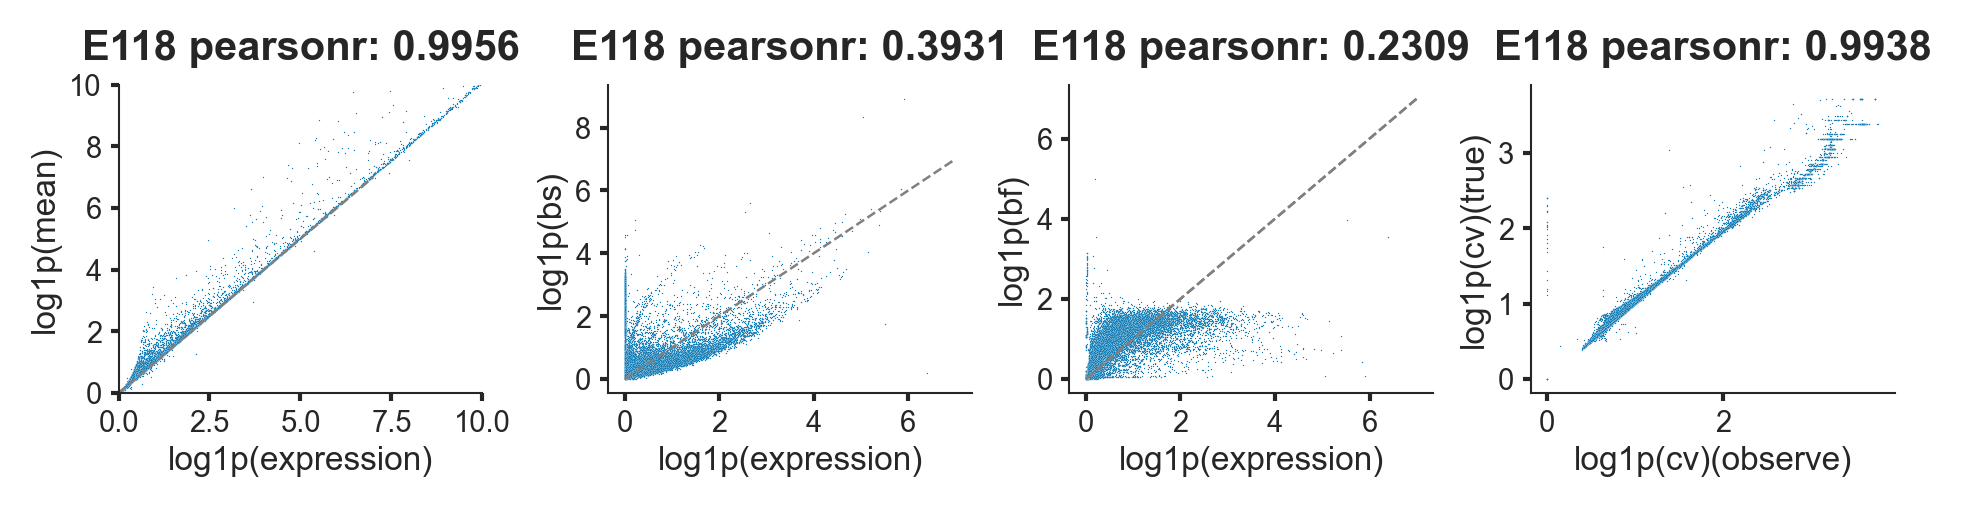

In [8]:
fig, ax = plt.subplots(1, 4, constrained_layout=True, figsize=(16/2.54, 4/2.54))

# sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['mean']),s=0.1,ax=ax[0])
sns.scatterplot(x=(meta_data['expression']),y=(meta_data['mean']),s=0.1,ax=ax[0])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[0])
# corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['mean']))
corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['mean']))
ax[0].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[0].set_xlabel('log1p(expression)')
ax[0].set_ylabel('log1p(mean)')
ax[0].set_ylim(0,10)
ax[0].set_xlim(0,10)


sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['bs']),s=0.1,ax=ax[1])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[1])
# corr_pearson, _ = pearsonr(np.log1p(meta_data['expression']), np.log1p(meta_data['bs']))
corr_pearson, _ = pearsonr((meta_data['expression']), (meta_data['bs']))
# corr_pearson, _ = pearsonr(meta_data['expression'], (meta_data['bs']))
ax[1].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[1].set_xlabel('log1p(expression)')
ax[1].set_ylabel('log1p(bs)')


sns.scatterplot(x=np.log1p(meta_data['expression']),y=np.log1p(meta_data['bf']),s=0.1,ax=ax[2])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[2])
corr_pearson, _ = pearsonr((meta_data['expression']), (meta_data['bf']))
ax[2].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[2].set_xlabel('log1p(expression)')
ax[2].set_ylabel('log1p(bf)')

sns.scatterplot(x=np.log1p(np.sqrt(meta_data['cv_1'])),y=np.log1p((meta_data['cv'])),s=0.1,ax=ax[3])
sns.lineplot(x=[0, 7], y=[0, 7], lw=0.6, color='gray', linestyle='--',ax=ax[2])
corr_pearson, _ = pearsonr(np.log1p(np.sqrt(meta_data['cv_1'])), np.log1p(meta_data['cv']))
ax[3].set_title(f"{eid} pearsonr: {corr_pearson:.4f}")
ax[3].set_xlabel('log1p(cv)(observe)')
ax[3].set_ylabel('log1p(cv)(true)')

plt.show()


In [39]:
bulk_exp_median =  np.median(meta_data['bulk_exp'])
mean_median = np.median(meta_data['mean'])
sc_exp_median = np.median(meta_data['expression'])

meta_data['bulk_exp_label'] = meta_data['bulk_exp'] > bulk_exp_median
meta_data['bulk_exp_label'] = np.int32(meta_data['bulk_exp_label'])

meta_data['mean_label'] = meta_data['mean'] > mean_median
meta_data['mean_label'] = np.int32(meta_data['mean_label'])

meta_data['sc_exp_label'] = meta_data['expression'] > sc_exp_median
meta_data['sc_exp_label'] = np.int32(meta_data['sc_exp_label'])

meta_data = meta_data[meta_data['mean_label'] == meta_data['bulk_exp_label']]

bs_median = np.median(meta_data['bs'])
bf_median = np.median(meta_data['bf'])
cv_median = np.median(meta_data['cv'])
# mean_median = np.median(meta_data['mean'])

meta_data['bs_label'] = meta_data.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
meta_data['bf_label'] = meta_data.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)
meta_data['cv_label'] = meta_data.apply(lambda row: 1 if row['cv'] > cv_median else 0, axis=1)
# meta_data['mean_label'] = meta_data.apply(lambda row: 1 if row['cv'] > mean_median else 0, axis=1)


In [40]:
meta_data
# meta_data_1[meta_data_1['sc_exp_label']==meta_data_1['mean_label']].describe()

,gene_id,eid,chrom,start,end,strand,neighbors,scores,expression,variance,...,k_syn,gene_name,bulk_exp,mean,bulk_exp_label,mean_label,sc_exp_label,bs_label,bf_label,cv_label
0,ENSG00000122417,E003,chr1,86862006,86862007,-,NaN,NaN,7.062315,152.070301,...,309.023993,ODF2L,5.509,7.626420,1,1,1,1,1,0
1,ENSG00000143320,E003,chr1,156675608,156675609,-,NaN,NaN,18.121662,597.976296,...,3035.783367,CRABP2,95.541,18.688951,1,1,1,1,1,0
2,ENSG00000143319,E003,chr1,156698231,156698232,-,NaN,NaN,5.456973,126.028564,...,1011.448030,ISG20L2,21.710,5.831277,1,1,1,1,1,0
3,ENSG00000143318,E003,chr1,160160363,160160364,+,NaN,NaN,0.100890,1.621869,...,17.661151,CASQ1,1.428,0.143615,0,0,0,1,0,1
4,ENSG00000143315,E003,chr1,160001780,160001781,-,NaN,NaN,3.931751,93.636292,...,136.474118,PIGM,15.004,4.080165,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17989,ENSG00000012817,E003,chrY,21906825,21906826,-,NaN,NaN,2.459941,36.206852,...,54.757974,KDM5D,4.846,2.641222,1,1,1,0,1,1
17990,ENSG00000187191,E003,chrY,26959639,26959640,-,NaN,NaN,0.000000,0.000000,...,1.000000,DAZ3,0.000,0.000012,0,0,0,0,0,0
17991,ENSG00000178605,E003,chrY,180887,180888,-,NaN,NaN,5.047478,96.490327,...,233.298782,GTPBP6,18.969,5.391179,1,1,1,0,1,0
17992,ENSG00000198692,E003,chrY,22737595,22737596,+,NaN,NaN,10.356083,219.131365,...,885.472501,EIF1AY,5.784,11.287297,1,1,1,0,1,0


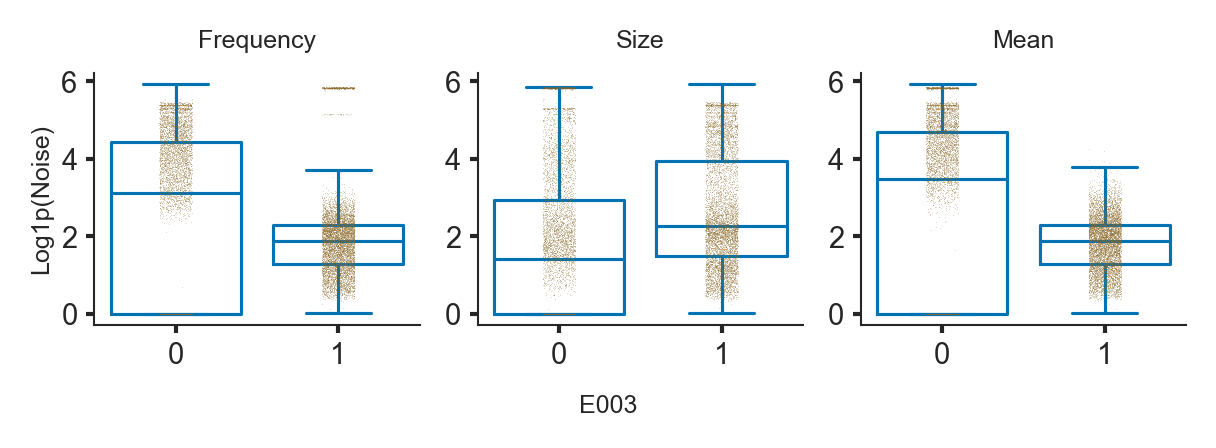

In [41]:
fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(10/2.54, 3.5/2.54))

# Plot without the 'order' parameter
sns.boxplot(x=meta_data['bf_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[0])
sns.stripplot(x=meta_data['bf_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[0])
ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('Log1p(Noise)',fontsize=6)
ax[0].set_xlabel('')

sns.boxplot(x=meta_data['bs_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[1])
sns.stripplot(x=meta_data['bs_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[1])
ax[1].set_title('Size',fontsize=6,fontweight='regular')
ax[1].set_ylabel('')
ax[1].set_xlabel('')


sns.boxplot(x=meta_data['mean_label'],y=np.log1p(meta_data['cv']),fill=None,fliersize=0,ax=ax[2])
sns.stripplot(x=meta_data['mean_label'],y=np.log1p(meta_data['cv']),s=0.1,ax=ax[2])
ax[2].set_title('Mean',fontsize=6,fontweight='regular')
ax[2].set_ylabel('')
ax[2].set_xlabel('')

fig.supxlabel(f'{eid}',fontsize=6)
# ax.tick_params(axis='both', labelsize=5, width=0.5, labelbottom=False, labelleft=True)
plt.show()

In [71]:
eid='E003'
delay = 0.2
data1 = pd.read_csv('extra/datasets/burst/processed/H1_statistic_gene_transcript_region.csv')
data2 = pd.read_csv(f'extra/datasets/burst/processed/H1_statistic_gene_transcript_region_delay_{delay}.csv')
gene_id2neighbors=f'extra/datasets/processed/v1/{eid}/gene_id2neighbors_{eid}.csv'
gene_id2neighbors = pd.read_csv(gene_id2neighbors, names=['gene_id','eid','chrom','start','end','strand','neighbors','scores'])


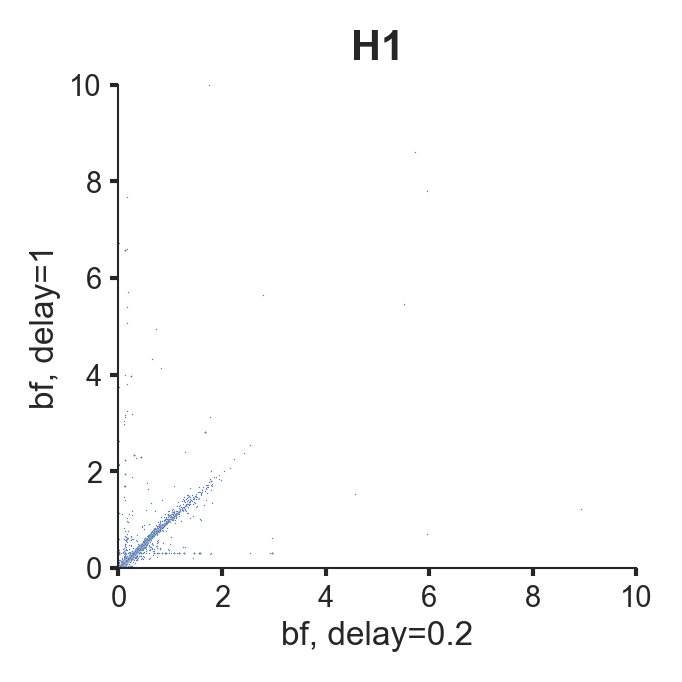

In [73]:
target = 'bf'
data = pd.merge(data1[['gene_id',target]],data2[['gene_id',target]],on='gene_id')
data = pd.merge(data,gene_id2neighbors[['gene_id']],on='gene_id')

ax = sns.scatterplot(x=(data[f'{target}_x']),y=(data[f'{target}_y']),s=0.1)
# ax = sns.scatterplot(x=np.log1p(data[f'{target}_x']),y=np.log1p(data[f'{target}_y']),s=0.1)
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_xlabel(f'{target}, delay={delay}')
ax.set_ylabel(f'{target}, delay=1')
ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}')
plt.show()

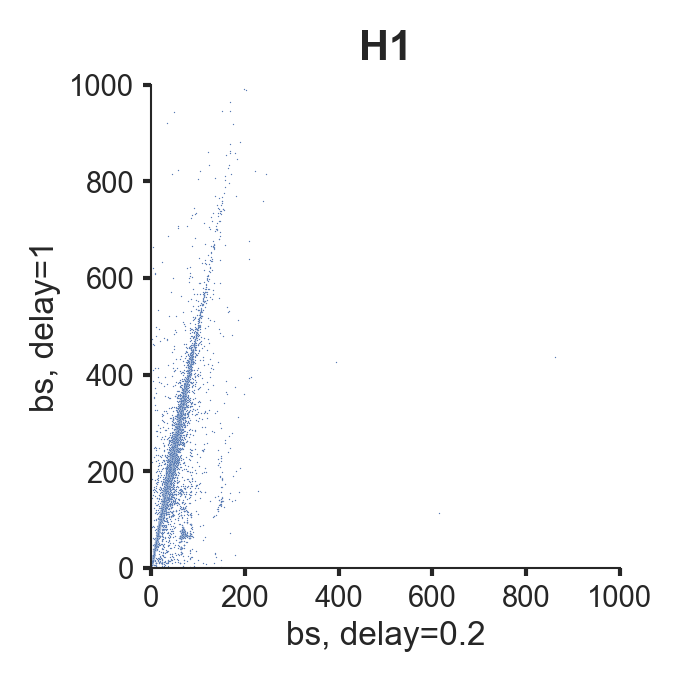

In [75]:

target = 'bs'
data = pd.merge(data1[['gene_id',target]],data2[['gene_id',target]],on='gene_id')
data = pd.merge(data,gene_id2neighbors[['gene_id']],on='gene_id')

ax = sns.scatterplot(x=(data[f'{target}_x']),y=(data[f'{target}_y']),s=0.1)
# ax = sns.scatterplot(x=np.log1p(data[f'{target}_x']),y=np.log1p(data[f'{target}_y']),s=0.1)
ax.set_xlim(0,1000)
ax.set_ylim(0,1000)
ax.set_xlabel(f'{target}, delay={delay}')
ax.set_ylabel(f'{target}, delay=1')
ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}')
plt.show()

In [3]:
import os
import pandas as pd
import numpy as np
eid = 'E118'
cell_type = EIDS_TO_CELLTYPES[eid]
data_dir = 'extra/datasets/burst/raw_data/'
# data_df = pd.read_csv(os.path.join(data_dir, cell_type, "H1_RNA.csv"), sep=',',index_col=0).T
data_df = pd.read_csv(os.path.join(data_dir ,cell_type,"HepG2_RNA.txt"), sep='\t').T
meta_data = pd.read_csv('extra/datasets/processed/v1/meta_datasets/meta_data_E003.csv')
def load_gene_name_code(data_dir, genes_type="features", gene_columns=["gene_id", "gene_name"]):
    """
    Load gene name and code information from a specified file.
    """
    genes_path = "{}/{}.tsv".format(data_dir, genes_type)
    genes = pd.read_csv(genes_path, header=None, sep='\t').iloc[:, :2]
    genes.columns = gene_columns
    return genes

gene_name_code = load_gene_name_code(os.path.join(data_dir,cell_type))
gene_name_set = pd.merge(meta_data['gene_id'],gene_name_code,on='gene_id')
gene_name_set = list(gene_name_set['gene_name'])

genes_for_burst = data_df[gene_name_set]
genes_for_burst.to_csv(os.path.join('tests/dataset_for_burst',f'{cell_type}.csv'))

In [4]:
import os
import pandas as pd
import numpy as np
eid = 'E118'
cell_type = EIDS_TO_CELLTYPES[eid]
data_dir = 'extra/datasets/burst/raw_data/'
# data_df = pd.read_csv(os.path.join(data_dir, cell_type, "H1_RNA.csv"), sep=',',index_col=0).T
data_df = pd.read_csv(os.path.join(data_dir ,cell_type,"HepG2_RNA.txt"), sep='\t').T
meta_data = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv')
def load_gene_name_code(data_dir, genes_type="features", gene_columns=["gene_id", "gene_name"]):
    """
    Load gene name and code information from a specified file.
    """
    genes_path = "{}/{}.tsv".format(data_dir, genes_type)
    genes = pd.read_csv(genes_path, header=None, sep='\t').iloc[:, :2]
    genes.columns = gene_columns
    return genes

gene_name_code = load_gene_name_code(os.path.join(data_dir,cell_type))
gene_name_set = pd.merge(meta_data['gene_id'],gene_name_code,on='gene_id')
gene_name_set = list(gene_name_set['gene_name'])

genes_for_burst = data_df[gene_name_set]
genes_for_burst.to_csv(os.path.join('tests/dataset_for_burst',f'{cell_type}.csv'))

In [5]:
import os
import pandas as pd
import numpy as np
eid = 'E116'
cell_type = EIDS_TO_CELLTYPES[eid]
data_dir = 'extra/datasets/burst/raw_data/'
data_df = pd.read_csv(os.path.join(data_dir, cell_type, "gm12878_processed_adata.csv"), sep=',',index_col=0)
meta_data = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv')
def load_gene_name_code(data_dir, genes_type="features", gene_columns=["gene_id", "gene_name"]):
    """
    Load gene name and code information from a specified file.
    """
    genes_path = "{}/{}.tsv".format(data_dir, genes_type)
    genes = pd.read_csv(genes_path, header=None, sep='\t').iloc[:, :2]
    genes.columns = gene_columns
    return genes

gene_name_code = load_gene_name_code(os.path.join(data_dir,cell_type))
gene_name_set = pd.merge(meta_data['gene_id'],gene_name_code,on='gene_id')
gene_name_set = list(gene_name_set['gene_name'])

genes_for_burst = data_df[gene_name_set]
genes_for_burst.to_csv(os.path.join('tests/dataset_for_burst',f'{cell_type}.csv'))

In [111]:

eid = 'E118'
labels_deeptx = pd.read_csv(f'extra/datasets/burst/labels/deeptx/{EIDS_TO_CELLTYPES[eid]}_estimated_burst.csv')
labels_deeptx = labels_deeptx.fillna(0.0)
bs_median = np.median(labels_deeptx['bs'])
bf_median = np.median(labels_deeptx['bf'])

labels_deeptx['bs_label'] = labels_deeptx.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
labels_deeptx['bf_label'] = labels_deeptx.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)
print(bs_median,bf_median)

labels_txburst = pd.read_csv(f'extra/datasets/burst/processed/{EIDS_TO_CELLTYPES[eid]}_statistic_gene_transcript_region.csv')
bs_median = np.median(labels_txburst['bs'])
bf_median = np.median(labels_txburst['bf'])
labels_txburst['mean'] = labels_txburst['bf']*labels_txburst['bs']


labels_txburst['bs_label'] = labels_txburst.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
labels_txburst['bf_label'] = labels_txburst.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)
print(bs_median,bf_median)

data = pd.merge(labels_deeptx[['gene_name','bf','bs',f'bf_label','bs_label','mean_true']],labels_txburst[['gene_name','bf','bs','bf_label','bs_label','mean']],on='gene_name')
# data = data[data['mean_true'] > 0.5]

data.to_csv('tests/test.csv',index=False)
# data[data[f'bf_label_x']==data[f'bf_label_y']]
data[data[f'bs_label_x']==data[f'bs_label_y']].shape[0]/data.shape[0]



2.7250026377901113 0.24855278833655695
0.5278995136770162 0.2237893168219122


0.811661134362823

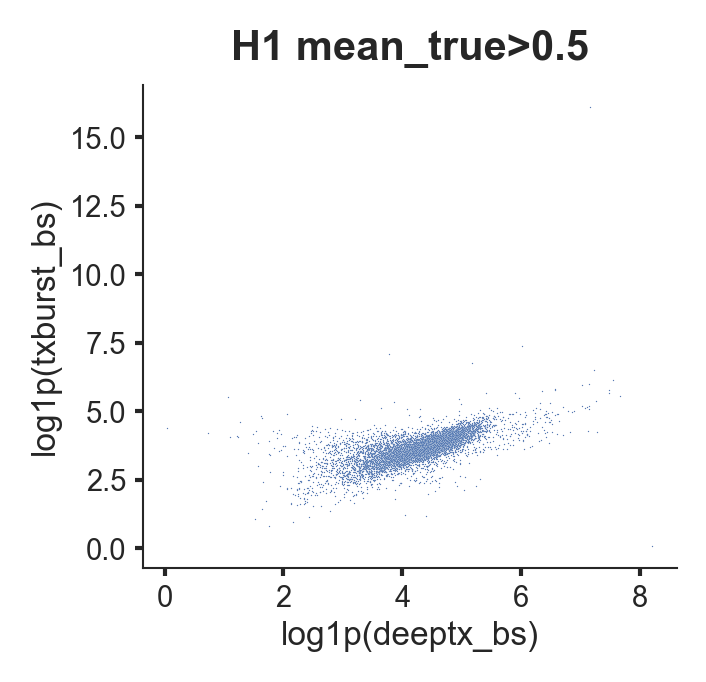

In [100]:
target = 'bs'
# data = pd.merge(labels_deeptx[['gene_name',target]],labels_txburst[['gene_name',target]],on='gene_name')
sns.scatterplot(x=np.log1p(data[f'{target}_x']),y=np.log1p(data[f'{target}_y']),s=0.1)
plt.xlabel(f'log1p(deeptx_{target})')
plt.ylabel(f'log1p(txburst_{target})')
plt.title(EIDS_TO_CELLTYPES[eid]+' mean_true>0.5')
plt.show()

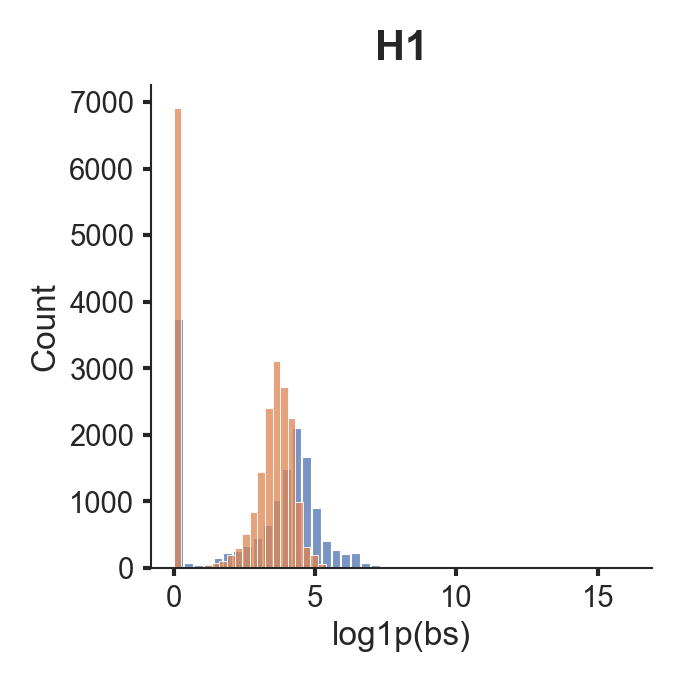

In [97]:
target = 'bs'
sns.histplot(np.log1p(labels_deeptx[target]))
sns.histplot(np.log1p(labels_txburst[target]))
plt.title(EIDS_TO_CELLTYPES[eid])
plt.xlabel(f'log1p({target})')
plt.show()

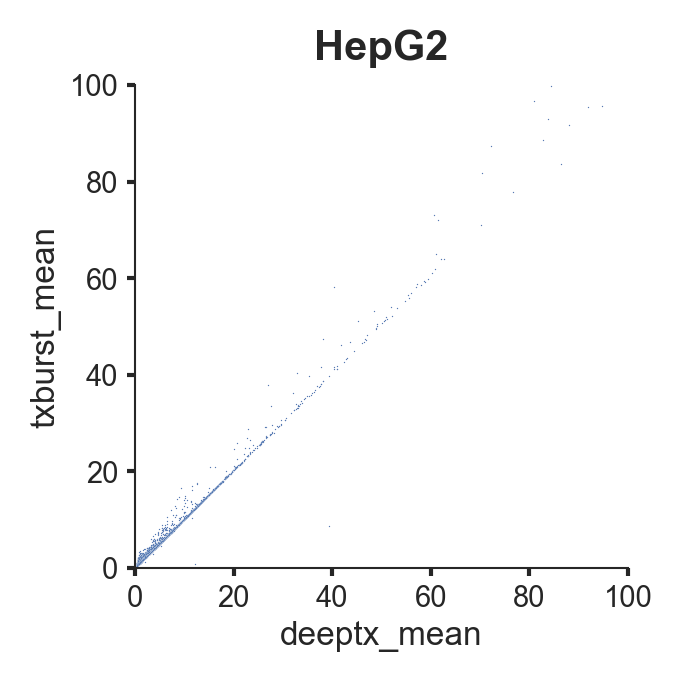

In [44]:
data = pd.merge(labels_deeptx[['gene_name',f'mean_true']],labels_txburst[['gene_name',f'mean']],on='gene_name')
# data[data[f'{target}_label_x']==data[f'{target}_label_y']].shape[0]/data.shape[0]

sns.scatterplot(x=data['mean_true'],y=data['mean'],s=0.1)
plt.xlim(0,100)
plt.ylim(0,100)
plt.xlabel('deeptx_mean')
plt.ylabel('txburst_mean')
plt.title(EIDS_TO_CELLTYPES[eid])
plt.show()

In [35]:
labels_txburst

,expression,variance,cv,bs,bf,k_on,k_off,k_syn,gene_name,gene_id,bs_label,bf_label
0,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,FAM138A,ENSG00000237613,0,0
1,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,OR4F5,ENSG00000186092,0,0
2,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,AP006222.2,ENSG00000286448,0,0
3,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,OR4F29,ENSG00000284733,0,0
4,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,OR4F16,ENSG00000284662,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22573,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,AC023491.2,ENSG00000278633,0,0
22574,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,AC233755.2,ENSG00000277856,0,0
22575,0.000000,0.000000,0.00000,0.012049,0.001000,0.001000,82.996168,1.000000,AC233755.1,ENSG00000275063,0,0
22576,1.566766,15.717352,2.53038,21.604855,0.081132,0.081132,0.911697,19.697081,AC240274.1,ENSG00000271254,0,1


In [ ]:

eid = 'E118'
labels_deeptx = pd.read_csv(f'extra/datasets/burst/labels/deeptx/{EIDS_TO_CELLTYPES[eid]}_estimated_burst.csv')
labels_deeptx = labels_deeptx.fillna(0.0)

# Figure3 superenhencer analysis

In [ ]:

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}

eid =  'E118'

super_enhencer = pd.read_csv(
    f'extra/datasets/diHMM/{EIDS_TO_CELLTYPES[eid]}/superenhancer.txt',
    sep='\t',
    header=None,
    names=['chrom', 'start', 'end', 'name','strand','gene_id']  # 你可以根据实际情况修改列名
)

super_enhencer = super_enhencer[['gene_id','name']].drop_duplicates()

data = pd.read_csv("extra/datasets/benchmark/Promoterformer/results/distance_region_predictions_bs_bf.csv")

data_1kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_pred']==1)]
# data_1kb = data_1kb[(data_1kb['bf_label_pred']==data_1kb['bf_label_label'])]

data_40kb = data[(data['eid']==eid) & (data['window_size']==40000) & (data['bf_label_pred']==0)]
# data_40kb = data_40kb[(data_40kb['bf_label_pred']==data_40kb['bf_label_label'])]
# data_40kb = data_40kb[~data_40kb['gene_id'].isin(data_1kb['gene_id'])]


gene_ids_1kbp = data_1kb['gene_id']
gene_ids_40kbp = data_40kb['gene_id']
gene_ids_1kbp_1 = pd.merge(super_enhencer,gene_ids_1kbp,on='gene_id').shape[0]
gene_ids_40kbp_1 = pd.merge(super_enhencer,gene_ids_40kbp,on='gene_id').shape[0]

print(gene_ids_1kbp_1/gene_ids_1kbp.shape[0],gene_ids_40kbp_1/gene_ids_40kbp.shape[0])


# Enformer prediction analysis

In [2]:
import numpy as np

def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
    """
    将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
    
    参数：
        matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
        bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
    
    返回：
        np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
    """
    length, C = matrix.shape
    assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
    
    n_bins = length // bin_size_bp  # 80
    binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
    return binned

In [3]:
import os
import pandas as pd 
from scipy.stats import pearsonr
from tqdm import tqdm
meta_data = pd.read_csv('extra/datasets/processed/v1/meta_datasets/meta_data_E003.csv')


In [13]:
corr = 0
corr_samples = []
for gene_id in tqdm(meta_data['gene_id'].unique()):
    path1 = os.path.join('extra/datasets/processed/v1/E003/regions', f'{gene_id}.npy')
    path2 = os.path.join('extra/datasets/processed/v1/E003_enformer', f'{gene_id}.npy')
    
    if not os.path.exists(path1) or not os.path.exists(path2):
        continue
    
    data1 = np.load(path1)[:7].T
    data1 = bin_40kbp_matrix(data1, bin_size_bp=500)
    # data1 = data1[39:41,:]
    data2 = np.load(path2)
    data2 = bin_40kbp_matrix(data2, bin_size_bp=500)
    # data2 = data2[39:41,:]
    corr_sample = 0
    for idx in range(7):
         corr_sample += pearsonr(np.log1p(data1[:,idx]), np.log1p(data2[:,idx]))[0]    

    corr_sample /= 7
    if np.isnan(corr_sample):
        corr_sample = 0.0
    corr += corr_sample 
    corr_samples.append(corr_sample)
    # print(f"Gene: {gene_id}, Pearson correlation: {corr_sample:.4f}")
print(f"Average Pearson correlation: {corr / len(meta_data['gene_id'].unique()):.4f}")
    

  2%|▏         | 285/14434 [00:03<02:31, 93.27it/s]/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_4557/2373291856.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_sample += pearsonr(np.log1p(data1[:,idx]), np.log1p(data2[:,idx]))[0]
100%|██████████| 14434/14434 [02:32<00:00, 94.73it/s]

Average Pearson correlation: 0.6905


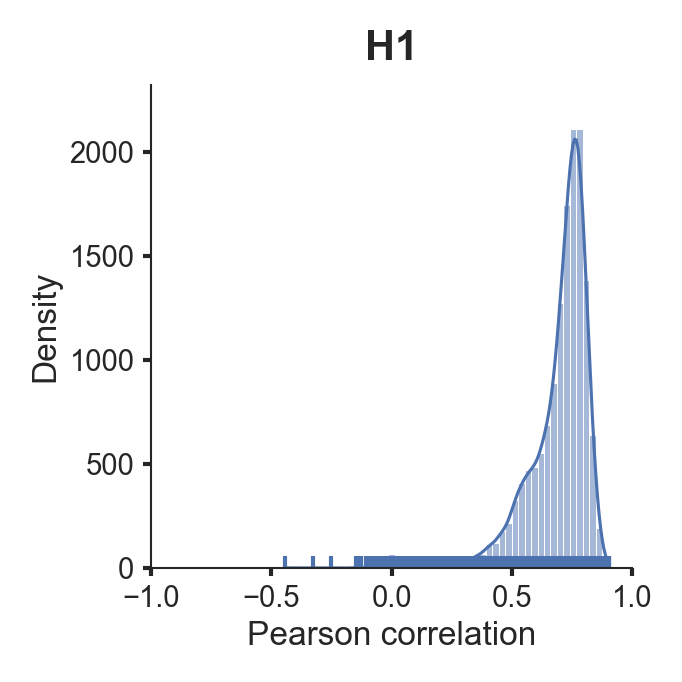

In [19]:
sns.histplot(corr_samples,bins=50,kde=True)
sns.rugplot(corr_samples)
plt.xlabel('Pearson correlation')
plt.ylabel('Density')
plt.title('H1')
plt.xlim(-1,1)
plt.show()